# Regressão de performance-por-post — grupo vídeo (Reels)

ADR [0019](../docs/adr/0019-regressao-de-performance-por-post-video-e-estatico-com-lasso-e-bertopic.md), parte D (issue #76). Roda a regressão do grupo vídeo via `src/modeling/post_performance.py` (issue C, já testado em `tests/test_post_performance.py`) e os testes de pressupostos do modelo linear (normalidade, homocedasticidade, independência, multicolinearidade) sobre os resíduos de **holdout** — é sobre generalização que esses pressupostos importam para a tese defendida, não sobre o ajuste ao próprio treino.

Este notebook não reimplementa treino/avaliação: só chama as funções de `post_performance.py`, para que notebook e pipeline de produção (`src/modeling/orchestration.py`) nunca divirjam sobre como o modelo é ajustado.

In [1]:
import sys
import os
# Adiciona o diretório raiz do projeto ao sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

from dotenv import load_dotenv
from config import settings
from src.repositories.delta_repository import DeltaRepository
from src.modeling.config import PostPerformanceConfig
from src.modeling.post_performance import (
    GRUPO_VIDEO,
    assemble_predictors,
    check_circularity,
    resolve_predictor_columns,
    select_holdout_governors,
    train_evaluate_group,
)

load_dotenv()
pd.set_option('display.float_format', '{:.4f}'.format)

repo = DeltaRepository(gold_dir=settings.GOLD_DIR, silver_dir=settings.SILVER_DIR)
config = PostPerformanceConfig()

## Leitura de dados

`df_reels` (Silver, `reels_clean`) já vem com `type_raw` (issue A) -- Reels não têm `caption`/`hashtags` no Bronze/Silver, então este grupo não tem os preditores Tema/comprimento de legenda (limitação estrutural, ver `PostPerformanceConfig` em `src/modeling/config.py`). `df_engagement` (Gold, `governor_engagement`) traz `_WC_COMENTARIO`/`FREQUENCIA`/`followersCount` por perfil.

In [2]:
df_reels = repo.load_reels()
df_engagement = repo.load_profiles()
print(f'{len(df_reels)} reels, {len(df_engagement)} governadores')

300 reels, 15 governadores


## Montagem de preditores + checagem de circularidade

`check_circularity` falha alto e cedo se algum preditor for uma das colunas brutas de Y (`likesCount`/`commentsCount`) ou tiver correlação > 0.95 com Y — o erro que motivou toda a ADR 0019.

In [3]:
df_assemblado = assemble_predictors(df_reels, df_engagement, GRUPO_VIDEO)
numeric_predictors, categorical_predictors = resolve_predictor_columns(
    df_assemblado, config, GRUPO_VIDEO
)
print('Preditores numéricos:', numeric_predictors)
print('Preditores categóricos:', categorical_predictors)

check_circularity(
    df_assemblado,
    'y',
    numeric_predictors,
    categorical_predictors,
    config.raw_target_columns,
    config.circularity_correlation_threshold,
)
print('Checagem de circularidade: OK, nenhum preditor circular encontrado.')

Preditores numéricos: ['hora_do_dia', 'FREQUENCIA', 'videoDuration', 'tem_duracao', 'videoPlayCount', 'paidPartnership']
Preditores categóricos: ['type_raw', 'dia_da_semana']
Checagem de circularidade: OK, nenhum preditor circular encontrado.


## Treino do modelo (Lasso, alpha por validação cruzada)

Holdout de governadores (não de posts individuais) — todos os posts de um governador em holdout ficam inteiramente fora do treino, eliminando o vazamento de identidade de perfil que motivou a ADR 0019 (decisão 5).

In [4]:
holdout_governors = select_holdout_governors(df_engagement['id'], config)
print(f'{len(holdout_governors)} governadores em holdout de {df_engagement["id"].nunique()}')

resultado = train_evaluate_group(
    df_assemblado,
    GRUPO_VIDEO,
    numeric_predictors,
    categorical_predictors,
    holdout_governors,
    config,
)
print(f'alpha (LassoCV): {resultado.alpha:.4f}')
print(f'R² treino: {resultado.r2_treino:.4f}')
print(f'R² holdout: {resultado.r2_holdout:.4f}')
print(f'n treino={resultado.n_treino}, n holdout={resultado.n_holdout}')

7 governadores em holdout de 15
alpha (LassoCV): 0.0030
R² treino: 0.0000
R² holdout: -0.9751
n treino=160, n holdout=140


## Coeficientes por preditor (ordenados por magnitude)

In [5]:
resultado.coeficientes[['preditor', 'coeficiente']]\
    .assign(coeficiente_abs=lambda df: df['coeficiente'].abs())\
    .sort_values('coeficiente_abs', ascending=False)\
    .drop(columns='coeficiente_abs')

,preditor,coeficiente
0,numericas__hora_do_dia,0.0000
1,numericas__FREQUENCIA,0.0000
2,numericas__videoDuration,0.0000
3,numericas__tem_duracao,0.0000
4,numericas__videoPlayCount,0.0000
5,numericas__paidPartnership,-0.0000
6,categoricas__type_raw_Video,0.0000
7,categoricas__dia_da_semana_domingo,0.0000
8,categoricas__dia_da_semana_quarta,-0.0000
9,categoricas__dia_da_semana_quinta,-0.0000


## Resíduos de holdout

Só o conjunto `holdout` de `resultado.previsoes` -- os testes de pressupostos abaixo rodam sobre generalização, não sobre ajuste ao treino (user story 7 da issue #76).

In [6]:
previsoes_holdout = resultado.previsoes[resultado.previsoes['conjunto'] == 'holdout']
residuos_holdout = previsoes_holdout['residuo'].to_numpy()
print(f'{len(residuos_holdout)} posts de holdout')
previsoes_holdout.head()

140 posts de holdout


,id,inputUrl,y_real,y_previsto,conjunto,grupo,residuo
160,gov0_reel_0,https://instagram.com/gov0,0.0030,0.0264,holdout,video,-0.0234
161,gov0_reel_1,https://instagram.com/gov0,0.0037,0.0264,holdout,video,-0.0227
162,gov0_reel_2,https://instagram.com/gov0,0.0171,0.0264,holdout,video,-0.0093
163,gov0_reel_3,https://instagram.com/gov0,0.0116,0.0264,holdout,video,-0.0148
164,gov0_reel_4,https://instagram.com/gov0,0.0093,0.0264,holdout,video,-0.0171


## Gráficos de diagnóstico

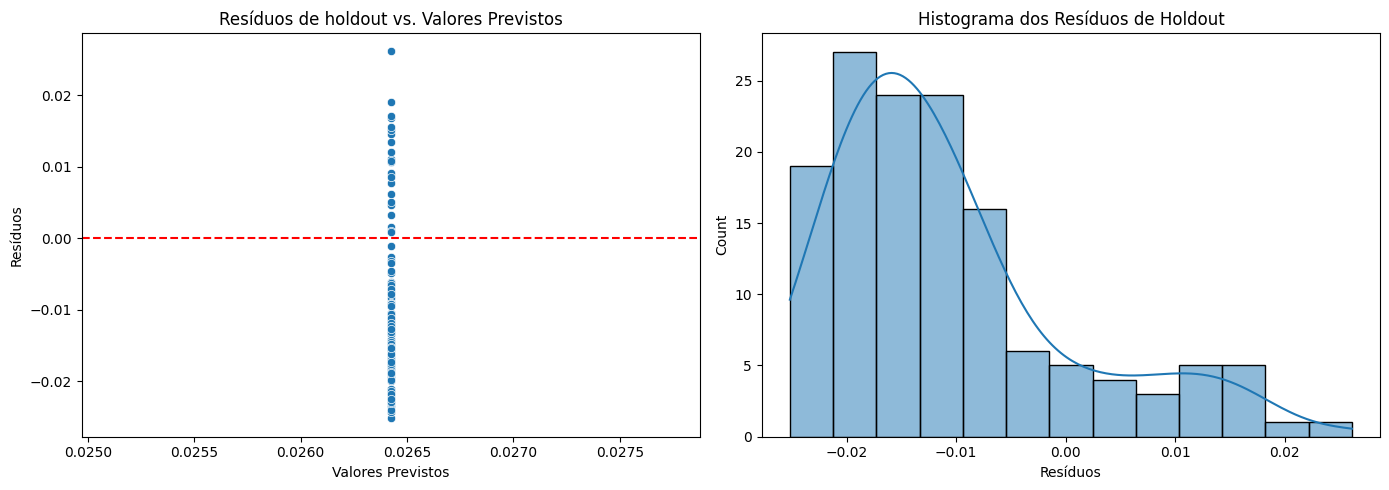

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=previsoes_holdout['y_previsto'], y=residuos_holdout, ax=axes[0]
)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Resíduos de holdout vs. Valores Previstos')
axes[0].set_xlabel('Valores Previstos')
axes[0].set_ylabel('Resíduos')

sns.histplot(residuos_holdout, kde=True, ax=axes[1])
axes[1].set_title('Histograma dos Resíduos de Holdout')
axes[1].set_xlabel('Resíduos')

plt.tight_layout()
plt.savefig('residuos_video.png')
plt.show()

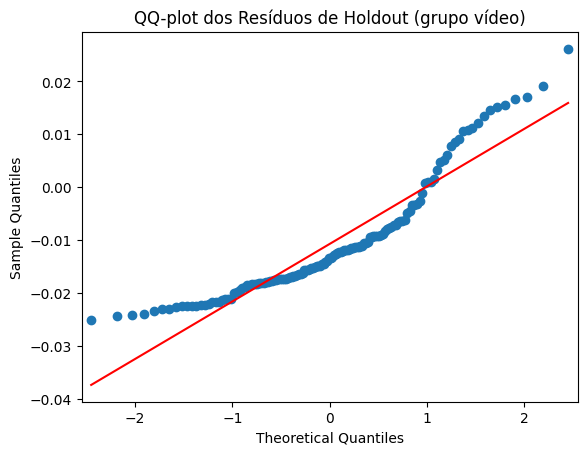

In [8]:
fig = sm.qqplot(residuos_holdout, line='s')
plt.title('QQ-plot dos Resíduos de Holdout (grupo vídeo)')
plt.savefig('qqplot_residuos_video.png')
plt.show()

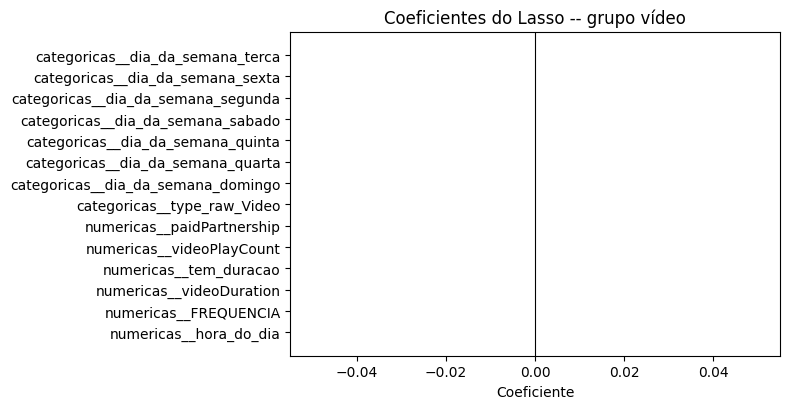

In [9]:
plt.figure(figsize=(8, max(4, len(resultado.coeficientes) * 0.3)))
coef_ordenados = resultado.coeficientes.sort_values('coeficiente')
plt.barh(coef_ordenados['preditor'], coef_ordenados['coeficiente'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Coeficientes do Lasso -- grupo vídeo')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.savefig('coeficientes_video.png')
plt.show()

## Testes de pressupostos do modelo linear (sobre resíduos de holdout)

Mesmo rigor acadêmico do `04_analise_regressao.ipynb` removido (Shapiro-Wilk, Durbin-Watson), completo com homocedasticidade (Breusch-Pagan) e multicolinearidade (VIF) -- especialmente relevante com os dummies de tópico do BERTopic somados aos demais preditores no grupo estático (não neste, que não tem Tema).

### Normalidade dos resíduos (Shapiro-Wilk)

In [10]:
shapiro_stat, shapiro_p = stats.shapiro(residuos_holdout)
print(f'Shapiro-Wilk: estatística={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}')
if shapiro_p > 0.05:
    print('Conclusão: resíduos de holdout consistentes com normalidade (p > 0.05).')
else:
    print('Conclusão: resíduos de holdout NÃO consistentes com normalidade (p <= 0.05).')

Shapiro-Wilk: estatística=0.8782, p-valor=0.0000
Conclusão: resíduos de holdout NÃO consistentes com normalidade (p <= 0.05).


### Independência/autocorrelação dos resíduos (Durbin-Watson)

In [11]:
dw = durbin_watson(residuos_holdout)
print(f'Durbin-Watson: {dw:.4f}')
if 1.5 < dw < 2.5:
    print('Conclusão: sem evidência de autocorrelação relevante nos resíduos.')
else:
    print('Conclusão: possível autocorrelação nos resíduos -- investigar.')

Durbin-Watson: 0.5973
Conclusão: possível autocorrelação nos resíduos -- investigar.


### Homocedasticidade (Breusch-Pagan) e multicolinearidade (VIF)

Reconstrói a matriz de preditores do holdout (mesmas colunas de `numeric_predictors`/`categorical_predictors`, com dummies para as categóricas) só para esses dois testes -- não repete nenhuma lógica de treino/avaliação, que continua vindo de `train_evaluate_group`.

In [12]:
df_holdout_diag = (
    df_assemblado[df_assemblado['ownerId'].isin(holdout_governors)]
    .merge(previsoes_holdout[['id', 'residuo']], on='id')
)
X_diag = pd.get_dummies(
    df_holdout_diag[numeric_predictors + categorical_predictors], drop_first=True
).astype(float)
X_diag_const = sm.add_constant(X_diag)

bp_stat, bp_p, _, _ = het_breuschpagan(df_holdout_diag['residuo'], X_diag_const)
print(f'Breusch-Pagan: estatística={bp_stat:.4f}, p-valor={bp_p:.4f}')
if bp_p > 0.05:
    print('Conclusão: sem evidência de heterocedasticidade (p > 0.05).')
else:
    print('Conclusão: possível heterocedasticidade nos resíduos (p <= 0.05).')

Breusch-Pagan: estatística=14.3184, p-valor=0.2159
Conclusão: sem evidência de heterocedasticidade (p > 0.05).


In [13]:
def calcular_vif(X_com_const: pd.DataFrame) -> pd.DataFrame:
    """VIF por preditor -- calculado sobre a matriz COM intercepto
    (mesma matriz usada no Breusch-Pagan acima), descartando a linha do
    próprio intercepto no resultado (não é um preditor real). Um
    preditor perfeitamente colinear com o intercepto (ex.: uma coluna
    constante) dá divisão por zero em `variance_inflation_factor`;
    reportado como infinito (multicolinearidade máxima), não um erro do
    notebook."""
    linhas = []
    for i, coluna in enumerate(X_com_const.columns):
        if coluna == 'const':
            continue
        try:
            vif = variance_inflation_factor(X_com_const.to_numpy(), i)
        except ZeroDivisionError:
            vif = float('inf')
        linhas.append({'preditor': coluna, 'VIF': vif})
    return pd.DataFrame(linhas)

vif_df = calcular_vif(X_diag_const).sort_values('VIF', ascending=False)
vif_df

,preditor,VIF
7,dia_da_semana_quinta,1.7768
9,dia_da_semana_segunda,1.7660
10,dia_da_semana_sexta,1.7462
11,dia_da_semana_terca,1.7327
8,dia_da_semana_sabado,1.7298
6,dia_da_semana_quarta,1.5549
5,paidPartnership,1.1294
0,hora_do_dia,1.0987
1,FREQUENCIA,1.0887
4,videoPlayCount,1.0830


In [14]:
preditores_colineares = vif_df[vif_df['VIF'] > 10]['preditor'].tolist()
if preditores_colineares:
    print(f'Conclusão: multicolinearidade preocupante (VIF > 10) em: {preditores_colineares}.')
else:
    print('Conclusão: sem evidência de multicolinearidade preocupante (todos os VIF <= 10).')

Conclusão: sem evidência de multicolinearidade preocupante (todos os VIF <= 10).
